# 打印目前项目中所有的文件路径

In [1]:
from pathlib import Path

root = Path(r"D:\Python\jupyter\jupyter\LFMCRegressor")

# 需要忽略的目录
ignore_dirs = {
    ".git", "__pycache__", ".pytest_cache", ".mypy_cache",
    ".venv", "venv", "env", "node_modules",
    "build", "dist", ".idea", ".vscode"
}

# 常见科研/代码文件后缀
include_exts = {
    ".py", ".ipynb", ".r", ".m", ".jl",
    ".cpp", ".c", ".h", ".hpp",
    ".java", ".scala", ".go", ".rs",
    ".js", ".ts",
    ".sh", ".bat", ".ps1",
    ".json", ".yaml", ".yml", ".toml", ".ini", ".cfg",
    ".txt", ".md", ".tex", ".csv"
}

files = []

for p in root.rglob("*"):
    if not p.is_file():
        continue
    if any(part in ignore_dirs for part in p.parts):
        continue
    if p.suffix.lower() in include_exts:
        files.append(p.relative_to(root).as_posix())

files.sort()

print(f"项目根目录: {root}")
print(f"文件总数: {len(files)}")
print("\n=== 文件路径索引 ===")
for i, f in enumerate(files, 1):
    print(f"{i:04d}. {f}")

项目根目录: D:\Python\jupyter\jupyter\LFMCRegressor
文件总数: 65

=== 文件路径索引 ===
0001. LFMCRegressor.ipynb
0002. README.md
0003. configs/auxvars.yaml
0004. configs/lfmc.yaml
0005. configs/paths.yaml
0006. configs/physics.yaml
0007. dataPreProcess.ipynb
0008. function/__init__.py
0009. function/auxvars/__init__.py
0010. function/auxvars/agb.py
0011. function/auxvars/canopy_height.py
0012. function/auxvars/glass_fvc.py
0013. function/auxvars/glass_lai.py
0014. function/auxvars/igbp.py
0015. function/auxvars/loader.py
0016. function/auxvars/lst.py
0017. function/auxvars/paths.py
0018. function/auxvars/utils_h5.py
0019. function/auxvars/utils_time_index.py
0020. function/extract_LC.py
0021. function/extract_lai.py
0022. function/io/__init__.py
0023. function/io/vod_mat.py
0024. function/lfmc/__init__.py
0025. function/lfmc/lfmc_clean.py
0026. function/lfmc/lfmc_dedup.py
0027. function/lfmc/lfmc_export.py
0028. function/lfmc/lfmc_io.py
0029. function/lfmc/lfmc_qc.py
0030. function/nc4_to_mat.py
0031

# 尝试进行第一次训练（3个波段，只使用H极化，需要获取的中间参数为eta和f_veg）

In [22]:
# Cell 1: imports + project path + read raw parquet

import math
import sys
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 路径与导入（绕过 function.physics.__init__.py）
# =========================
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PHYSICS_DIR = PROJECT_ROOT / "function" / "physics"
if str(PHYSICS_DIR) not in sys.path:
    sys.path.insert(0, str(PHYSICS_DIR))

import constant
import mixing
import vegetation_dielectric

SRC_FP = r"G:\data\Globe LFMC\processed\lfmc_base_0p1.parquet"
df_raw = pd.read_parquet(SRC_FP)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PHYSICS_DIR  =", PHYSICS_DIR)
print(df_raw.shape)
print(df_raw.columns.tolist()[:40])


PROJECT_ROOT = D:\Python\jupyter\jupyter\LFMCRegressor
PHYSICS_DIR  = D:\Python\jupyter\jupyter\LFMCRegressor\function\physics
(140112, 35)
['date', 'row', 'col', 'lfmc_pct', 'veg_type', 'tau_Ku_H', 'tau_Ku_V', 'tau_X_H', 'tau_X_V', 'tau_C_H', 'tau_C_V', 'canopy_height', 'agb', 'lai', 'fvc', 'lst', 'lai_index_date', 'fvc_index_date', 'igbp_ENF', 'igbp_EBF', 'igbp_DNF', 'igbp_DBF', 'igbp_MF', 'igbp_CSH', 'igbp_OSH', 'igbp_WSA', 'igbp_SAV', 'igbp_GRA', 'igbp_WET', 'igbp_CRO', 'igbp_URB', 'igbp_CVM', 'igbp_SNO', 'igbp_BAR', 'igbp_WAT']


In [23]:
# Cell 2: config and required columns

FEATURE_COLS = [
    "agb", "lai", "fvc",
    "igbp_ENF", "igbp_EBF", "igbp_DNF", "igbp_DBF", "igbp_MF",
    "igbp_CSH", "igbp_OSH", "igbp_WSA", "igbp_SAV", "igbp_GRA",
    "igbp_WET", "igbp_CRO", "igbp_URB", "igbp_CVM", "igbp_SNO",
    "igbp_BAR", "igbp_WAT",
]

BAND_TO_COL = {
    "C": "tau_C_H",
    "X": "tau_X_H",
    "Ku": "tau_Ku_H",
}
BAND_TO_FREQ = {
    "C": 6.9e9,
    "X": 10.65e9,
    "Ku": 18.7e9,
}

required_cols = [
    "lfmc_pct", "canopy_height",
    "tau_C_H", "tau_X_H", "tau_Ku_H",
    *FEATURE_COLS,
    "row", "col",
]

missing = [c for c in required_cols if c not in df_raw.columns]
print("missing:", missing)
if missing:
    raise ValueError(f"缺少列: {missing}")


missing: []


In [24]:
# Cell 3: 0.5° spatial split with ratio 8:1:1

SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

df = df_raw.copy().reset_index(drop=True)

# 0.1° row/col -> 0.5° block = 5x5 cells
df["block_row_05deg"] = (df["row"] // 5).astype(int)
df["block_col_05deg"] = (df["col"] // 5).astype(int)
df["block_id_05deg"] = (
    df["block_row_05deg"].astype(str) + "_" + df["block_col_05deg"].astype(str)
)

blocks = np.array(sorted(df["block_id_05deg"].dropna().unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(blocks)

n_blocks = len(blocks)
n_train = int(round(n_blocks * TRAIN_RATIO))
n_val = int(round(n_blocks * VAL_RATIO))
n_test = n_blocks - n_train - n_val

train_blocks = set(blocks[:n_train])
val_blocks = set(blocks[n_train:n_train + n_val])
test_blocks = set(blocks[n_train + n_val:])

def assign_split(block_id):
    if block_id in train_blocks:
        return "train"
    if block_id in val_blocks:
        return "val"
    return "test"

df["split"] = df["block_id_05deg"].map(assign_split)

print("num blocks =", n_blocks)
print(df["split"].value_counts(dropna=False))
print(df.groupby("split")["block_id_05deg"].nunique())


num blocks = 774
split
train    115827
val       13232
test      11053
Name: count, dtype: int64
split
test      78
train    619
val       77
Name: block_id_05deg, dtype: int64


In [26]:
# Cell 4: spatial independence check

block_sets = {
    s: set(df.loc[df["split"] == s, "block_id_05deg"].unique())
    for s in ["train", "val", "test"]
}

print("train ∩ val :", len(block_sets["train"] & block_sets["val"]))
print("train ∩ test:", len(block_sets["train"] & block_sets["test"]))
print("val ∩ test  :", len(block_sets["val"] & block_sets["test"]))

assert len(block_sets["train"] & block_sets["val"]) == 0
assert len(block_sets["train"] & block_sets["test"]) == 0
assert len(block_sets["val"] & block_sets["test"]) == 0

print("空间独立性检查通过。")


train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0
空间独立性检查通过。


In [27]:
# Cell 5: reconstruct lat/lon from row/col and keep them in outputs

LAT0 = 89.95
LON0 = -179.95
RES = 0.1

df["grid_lat"] = LAT0 - df["row"] * RES
df["grid_lon"] = LON0 + df["col"] * RES

df["block_lat_center"] = LAT0 - (df["block_row_05deg"] * 5 + 2) * RES
df["block_lon_center"] = LON0 + (df["block_col_05deg"] * 5 + 2) * RES

df[[
    "row", "col", "grid_lat", "grid_lon",
    "block_id_05deg", "block_lat_center", "block_lon_center", "split"
]].head()


,row,col,grid_lat,grid_lon,block_id_05deg,block_lat_center,block_lon_center,split
0,527,578,37.25,-122.15,105_115,37.25,-122.25,train
1,525,576,37.45,-122.35,105_115,37.25,-122.25,train
2,529,581,37.05,-121.85,105_116,37.25,-121.75,train
3,529,581,37.05,-121.85,105_116,37.25,-121.75,train
4,525,576,37.45,-122.35,105_115,37.25,-122.25,train


In [28]:
# Cell 6: save train/val/test parquet

OUT_DIR = PROJECT_ROOT / "data_spatial_split_05deg"
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_fp = OUT_DIR / "train_05deg.parquet"
val_fp   = OUT_DIR / "val_05deg.parquet"
test_fp  = OUT_DIR / "test_05deg.parquet"

df_train_wide = df.loc[df["split"] == "train"].copy()
df_val_wide   = df.loc[df["split"] == "val"].copy()
df_test_wide  = df.loc[df["split"] == "test"].copy()

df_train_wide.to_parquet(train_fp, index=False)
df_val_wide.to_parquet(val_fp, index=False)
df_test_wide.to_parquet(test_fp, index=False)

print("saved:")
print(train_fp, df_train_wide.shape)
print(val_fp, df_val_wide.shape)
print(test_fp, df_test_wide.shape)


saved:
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\train_05deg.parquet (115827, 43)
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\val_05deg.parquet (13232, 43)
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\test_05deg.parquet (11053, 43)


In [37]:
# Cell 7: helpers

def wide_to_long_h(df_wide: pd.DataFrame) -> pd.DataFrame:
    base = df_wide.copy().reset_index(drop=True)
    base["sample_id"] = np.arange(len(base), dtype=np.int64)

    base = base.dropna(subset=["lfmc_pct", "canopy_height"]).copy()
    has_any_h = base[list(BAND_TO_COL.values())].notna().any(axis=1)
    base = base.loc[has_any_h].copy()

    parts = []
    for band, tau_col in BAND_TO_COL.items():
        tmp = base[["sample_id", "lfmc_pct", "canopy_height"] + FEATURE_COLS].copy()
        tmp["band"] = band
        tmp["vod_obs"] = base[tau_col].values
        tmp = tmp.dropna(subset=["vod_obs"]).copy()
        parts.append(tmp)

    return pd.concat(parts, ignore_index=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_vegf_proxy(df):
    lai = df["lai"].astype(float).fillna(0.0).to_numpy()
    fvc = df["fvc"].astype(float).fillna(0.0).to_numpy()
    agb = df["agb"].astype(float).fillna(0.0).to_numpy()

    lai_term = 1.0 - np.exp(-0.6 * np.clip(lai, 0, None))
    agb_term = 1.0 - np.exp(-np.clip(agb, 0, None) / 120.0)

    vegf = 0.50 * np.clip(fvc, 0, 1) + 0.30 * lai_term + 0.20 * agb_term
    return np.clip(vegf, 0.0, 1.0)

def vod_from_lfmc_vegf_eta(lfmc_pct, vegf, hveg_m, band, eta_h):
    f_hz = BAND_TO_FREQ[band]
    lam = constant.wavelength_from_freq(f_hz)
    f_ghz = f_hz / 1e9

    eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
        lfmc_pct=np.asarray([lfmc_pct], dtype=float),
        f_ghz=np.asarray([f_ghz], dtype=float),
        model="ulaby_dc",
        temp_c=None,
        salinity_permil=None,
        salinity_default_permil=0.0,
        clip_vfw_nonneg=True,
        clip_loss_nonneg=True,
    )[0]

    eps_can = mixing.power_law_air_veg(
        eps_veg=np.asarray([eps_veg], dtype=np.complex128),
        vegf=np.asarray([vegf], dtype=float),
        beta=1.0 / 3.0,
    )[0]

    sqrt_eps = np.sqrt(eps_can)
    im_term = -np.imag(sqrt_eps)
    vod = eta_h * (4.0 * np.pi * hveg_m / lam) * im_term
    return float(max(vod, 0.0))


In [38]:
# Cell 8: build long tables

train_df_long = wide_to_long_h(df_train_wide)
val_df_long   = wide_to_long_h(df_val_wide)
test_df_long  = wide_to_long_h(df_test_wide)

print(train_df_long.shape, val_df_long.shape, test_df_long.shape)
print(train_df_long["band"].value_counts())


(138598, 25) (16440, 25) (16511, 25)
band
X     46874
C     46745
Ku    44979
Name: count, dtype: int64


In [39]:
# Cell 9: LFMC strong baseline

X_train_wide = df_train_wide[FEATURE_COLS].copy()
X_val_wide   = df_val_wide[FEATURE_COLS].copy()
X_test_wide  = df_test_wide[FEATURE_COLS].copy()

y_train_lfmc = df_train_wide["lfmc_pct"].astype(float).to_numpy()
y_val_lfmc   = df_val_wide["lfmc_pct"].astype(float).to_numpy()
y_test_lfmc  = df_test_wide["lfmc_pct"].astype(float).to_numpy()

lfmc_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)
lfmc_model.fit(X_train_wide, y_train_lfmc)

df_train_wide["lfmc_hat"] = lfmc_model.predict(X_train_wide)
df_val_wide["lfmc_hat"]   = lfmc_model.predict(X_val_wide)
df_test_wide["lfmc_hat"]  = lfmc_model.predict(X_test_wide)

print("LFMC train RMSE:", rmse(df_train_wide["lfmc_pct"], df_train_wide["lfmc_hat"]))
print("LFMC val   RMSE:", rmse(df_val_wide["lfmc_pct"], df_val_wide["lfmc_hat"]))
print("LFMC test  RMSE:", rmse(df_test_wide["lfmc_pct"], df_test_wide["lfmc_hat"]))


LFMC train RMSE: 34.95470561772419
LFMC val   RMSE: 35.99135333811061
LFMC test  RMSE: 36.71240927327642


In [40]:
# Cell 10: vegf baseline from proxy

df_train_wide["vegf_proxy"] = make_vegf_proxy(df_train_wide)
df_val_wide["vegf_proxy"]   = make_vegf_proxy(df_val_wide)
df_test_wide["vegf_proxy"]  = make_vegf_proxy(df_test_wide)

vegf_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=4,
    max_iter=250,
    min_samples_leaf=30,
    l2_regularization=0.5,
    random_state=42,
)
vegf_model.fit(X_train_wide, df_train_wide["vegf_proxy"].to_numpy())

df_train_wide["vegf_hat"] = np.clip(vegf_model.predict(X_train_wide), 0.0, 1.0)
df_val_wide["vegf_hat"]   = np.clip(vegf_model.predict(X_val_wide), 0.0, 1.0)
df_test_wide["vegf_hat"]  = np.clip(vegf_model.predict(X_test_wide), 0.0, 1.0)

print("vegf train proxy RMSE:", rmse(df_train_wide["vegf_proxy"], df_train_wide["vegf_hat"]))
print("vegf val   proxy RMSE:", rmse(df_val_wide["vegf_proxy"], df_val_wide["vegf_hat"]))
print("vegf test  proxy RMSE:", rmse(df_test_wide["vegf_proxy"], df_test_wide["vegf_hat"]))


vegf train proxy RMSE: 0.003546744004608571
vegf val   proxy RMSE: 0.004396088422223402
vegf test  proxy RMSE: 0.004275584034031519


In [41]:
# Cell 11: fit eta_H(canopy_height) using training set only

df_train_wide = df_train_wide.reset_index(drop=True).copy()
df_val_wide   = df_val_wide.reset_index(drop=True).copy()
df_test_wide  = df_test_wide.reset_index(drop=True).copy()

df_train_wide["sample_id"] = np.arange(len(df_train_wide), dtype=np.int64)
df_val_wide["sample_id"]   = np.arange(len(df_val_wide), dtype=np.int64)
df_test_wide["sample_id"]  = np.arange(len(df_test_wide), dtype=np.int64)

train_df_long = wide_to_long_h(df_train_wide)
val_df_long   = wide_to_long_h(df_val_wide)
test_df_long  = wide_to_long_h(df_test_wide)

train_eta_df = train_df_long.merge(
    df_train_wide[["sample_id", "vegf_hat"]],
    on="sample_id",
    how="left"
)

eta_targets = []
for rec in train_eta_df.itertuples(index=False):
    f_hz = BAND_TO_FREQ[rec.band]
    lam = constant.wavelength_from_freq(f_hz)
    f_ghz = f_hz / 1e9

    eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
        lfmc_pct=np.asarray([rec.lfmc_pct], dtype=float),
        f_ghz=np.asarray([f_ghz], dtype=float),
        model="ulaby_dc",
        temp_c=None,
        salinity_permil=None,
        salinity_default_permil=0.0,
        clip_vfw_nonneg=True,
        clip_loss_nonneg=True,
    )[0]

    eps_can = mixing.power_law_air_veg(
        eps_veg=np.asarray([eps_veg], dtype=np.complex128),
        vegf=np.asarray([rec.vegf_hat], dtype=float),
        beta=1.0 / 3.0,
    )[0]

    base_term = (4.0 * np.pi * rec.canopy_height / lam) * (-np.imag(np.sqrt(eps_can)))

    if np.isfinite(base_term) and base_term > 1e-8 and np.isfinite(rec.vod_obs):
        eta_t = rec.vod_obs / base_term
    else:
        eta_t = np.nan

    eta_targets.append(eta_t)

train_eta_df["eta_target"] = eta_targets
train_eta_df = train_eta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["eta_target"]).copy()

lo = train_eta_df["eta_target"].quantile(0.01)
hi = train_eta_df["eta_target"].quantile(0.99)
train_eta_df["eta_target_clip"] = train_eta_df["eta_target"].clip(lo, hi)

eta_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=3,
    max_iter=200,
    min_samples_leaf=50,
    l2_regularization=1.0,
    random_state=42,
)
eta_model.fit(
    train_eta_df[["canopy_height"]],
    train_eta_df["eta_target_clip"]
)

print(train_eta_df[["canopy_height", "eta_target", "eta_target_clip"]].describe())


       canopy_height     eta_target  eta_target_clip
count  135508.000000  135508.000000    135508.000000
mean       10.043157       0.334587         0.221031
std         8.367840       2.744803         1.197693
min         0.002066       0.000037         0.000083
25%         1.666008       0.000357         0.000357
50%         9.389328       0.000990         0.000990
75%        16.306324       0.008539         0.008539
max        39.529644     193.167812        10.219330


In [42]:
# Cell 12: attach predictions and compute VOD_hat

def attach_predictions(wide_df, long_df):
    wide_keep = wide_df[["sample_id", "lfmc_hat", "vegf_hat"]].copy()
    out = long_df.merge(wide_keep, on="sample_id", how="left")
    out["eta_h"] = np.clip(
        eta_model.predict(out[["canopy_height"]]),
        1e-6,
        None
    )

    vod_hat = []
    for rec in out.itertuples(index=False):
        vod_hat.append(
            vod_from_lfmc_vegf_eta(
                lfmc_pct=rec.lfmc_hat,
                vegf=rec.vegf_hat,
                hveg_m=rec.canopy_height,
                band=rec.band,
                eta_h=rec.eta_h
            )
        )
    out["vod_hat"] = vod_hat
    return out

train_pred_long = attach_predictions(df_train_wide, train_df_long)
val_pred_long   = attach_predictions(df_val_wide, val_df_long)
test_pred_long  = attach_predictions(df_test_wide, test_df_long)


In [44]:
# Cell 13: final metrics

print("LFMC")
print("  train RMSE:", rmse(df_train_wide["lfmc_pct"], df_train_wide["lfmc_hat"]))
print("  val   RMSE:", rmse(df_val_wide["lfmc_pct"], df_val_wide["lfmc_hat"]))
print("  test  RMSE:", rmse(df_test_wide["lfmc_pct"], df_test_wide["lfmc_hat"]))

print("\nVOD(H)")
print("  train RMSE:", rmse(train_pred_long["vod_obs"], train_pred_long["vod_hat"]))
print("  val   RMSE:", rmse(val_pred_long["vod_obs"], val_pred_long["vod_hat"]))
print("  test  RMSE:", rmse(test_pred_long["vod_obs"], test_pred_long["vod_hat"]))

print("  train MAE :", mean_absolute_error(train_pred_long["vod_obs"], train_pred_long["vod_hat"]))
print("  val   MAE :", mean_absolute_error(val_pred_long["vod_obs"], val_pred_long["vod_hat"]))
print("  test  MAE :", mean_absolute_error(test_pred_long["vod_obs"], test_pred_long["vod_hat"]))

val_pred_long[[
    "sample_id", "band", "canopy_height",
    "lfmc_pct", "lfmc_hat",
    "vegf_hat", "eta_h",
    "vod_obs", "vod_hat"
]].head(10)


LFMC
  train RMSE: 34.95470561772419
  val   RMSE: 35.99135333811061
  test  RMSE: 36.71240927327642

VOD(H)
  train RMSE: 1.6552687278519491
  val   RMSE: 1.2973761516914855
  test  RMSE: 1.7008885166670908
  train MAE : 0.9885357895260503
  val   MAE : 0.8129901823072294
  test  MAE : 0.8837819935757834


,sample_id,band,canopy_height,lfmc_pct,lfmc_hat,vegf_hat,eta_h,vod_obs,vod_hat
0,872,C,0.010331,62.5,89.506652,0.054326,1.692945,0.507015,0.107915
1,875,C,0.006198,166.0,91.858402,0.080214,4.184362,0.491621,0.242071
2,876,C,0.401186,161.0,69.572468,0.097844,0.065261,0.505196,0.273247
3,877,C,0.041502,206.0,128.478796,0.132461,0.660300,0.601497,0.480850
4,883,C,0.010331,58.0,87.938364,0.053247,1.692945,0.338535,0.105115
5,884,C,0.006198,144.0,91.858402,0.077308,4.184362,0.560352,0.232883
6,885,C,0.401186,131.0,69.572468,0.097844,0.065261,0.379556,0.273247
7,886,C,0.041502,167.0,127.255720,0.120372,0.660300,0.637057,0.432426
8,894,C,4.601240,95.0,103.062052,0.269628,0.002919,0.797765,0.486577
9,895,C,0.006198,100.0,91.858402,0.077308,4.184362,0.521536,0.232883


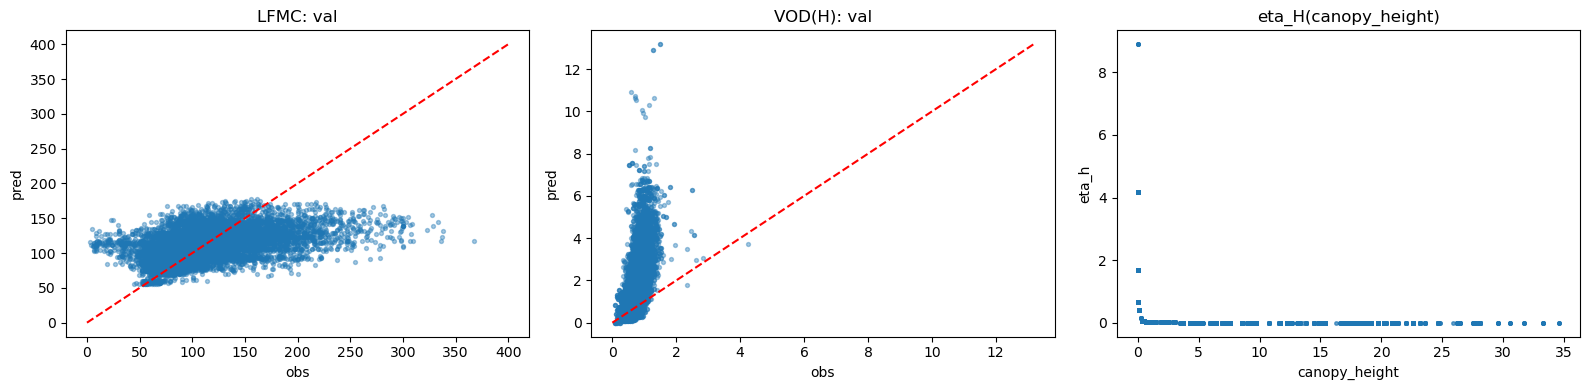

In [45]:
# Cell 14: optional plots

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df_val_wide["lfmc_pct"], df_val_wide["lfmc_hat"], s=8, alpha=0.4)
axes[0].plot([0, 400], [0, 400], "r--")
axes[0].set_title("LFMC: val")
axes[0].set_xlabel("obs")
axes[0].set_ylabel("pred")

axes[1].scatter(val_pred_long["vod_obs"], val_pred_long["vod_hat"], s=8, alpha=0.4)
mn = min(val_pred_long["vod_obs"].min(), val_pred_long["vod_hat"].min())
mx = max(val_pred_long["vod_obs"].max(), val_pred_long["vod_hat"].max())
axes[1].plot([mn, mx], [mn, mx], "r--")
axes[1].set_title("VOD(H): val")
axes[1].set_xlabel("obs")
axes[1].set_ylabel("pred")

tmp = val_pred_long[["canopy_height", "eta_h"]].sort_values("canopy_height")
axes[2].scatter(tmp["canopy_height"], tmp["eta_h"], s=6, alpha=0.3)
axes[2].set_title("eta_H(canopy_height)")
axes[2].set_xlabel("canopy_height")
axes[2].set_ylabel("eta_h")

plt.tight_layout()
plt.show()


# eta与树高无关，重新尝试训练

PROJECT_ROOT = D:\Python\jupyter\jupyter\LFMCRegressor
PHYSICS_DIR  = D:\Python\jupyter\jupyter\LFMCRegressor\function\physics
raw shape before filter = (140112, 35)
raw shape after  filter = (138374, 35)

num blocks = 765
split
train    114560
test      13657
val       10157
Name: count, dtype: int64
split
test      77
train    612
val       76
Name: block_id_05deg, dtype: int64
空间独立性检查通过。

saved:
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\train_05deg.parquet (114560, 43)
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\val_05deg.parquet (10157, 43)
D:\Python\jupyter\jupyter\LFMCRegressor\data_spatial_split_05deg\test_05deg.parquet (13657, 43)

long-table shapes:
(133147, 25) (14433, 25) (20813, 25)
band
X     45112
C     44968
Ku    43067
Name: count, dtype: int64

LFMC
  train RMSE: 34.14075631447829
  val   RMSE: 37.78715190093366
  test  RMSE: 41.23608939512626

vegf proxy fit
  train RMSE: 0.0035749009050783584
  val   RMSE: 0.004967567129531

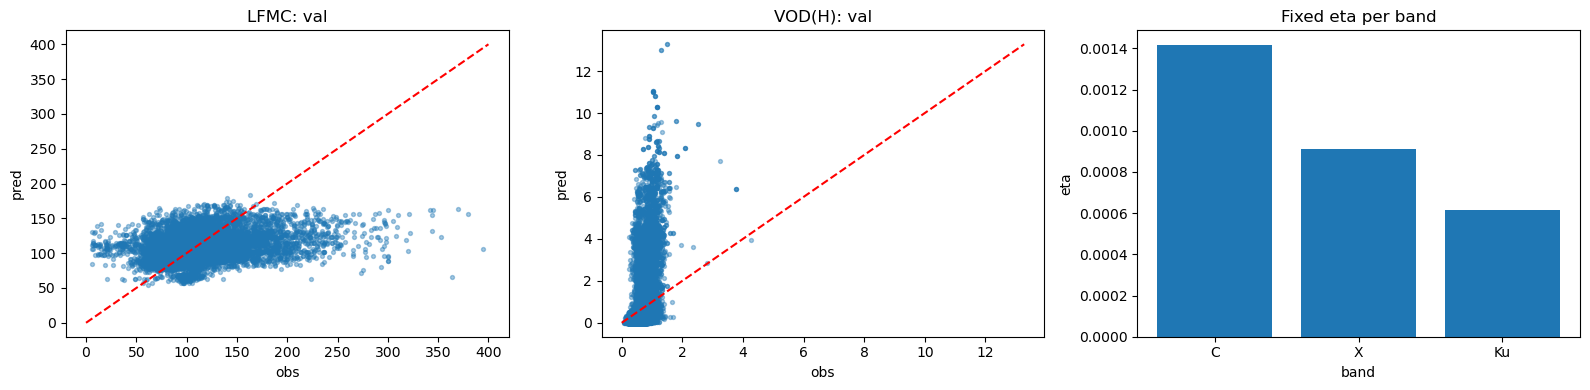

In [49]:
import math
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 0) 路径与导入（绕过 function.physics.__init__.py）
# =========================
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

PHYSICS_DIR = PROJECT_ROOT / "function" / "physics"
if str(PHYSICS_DIR) not in sys.path:
    sys.path.insert(0, str(PHYSICS_DIR))

import constant
import mixing
import vegetation_dielectric

# =========================
# 1) 读取原始 parquet
# =========================
SRC_FP = r"G:\data\Globe LFMC\processed\lfmc_base_0p1.parquet"
df_raw = pd.read_parquet(SRC_FP)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PHYSICS_DIR  =", PHYSICS_DIR)
print("raw shape before filter =", df_raw.shape)

# 去除 canopy_height <= 0 的无效记录
df_raw = df_raw[df_raw["canopy_height"] > 0].copy()

print("raw shape after  filter =", df_raw.shape)

# =========================
# 2) 配置
# =========================
FEATURE_COLS = [
    "agb", "lai", "fvc",
    "igbp_ENF", "igbp_EBF", "igbp_DNF", "igbp_DBF", "igbp_MF",
    "igbp_CSH", "igbp_OSH", "igbp_WSA", "igbp_SAV", "igbp_GRA",
    "igbp_WET", "igbp_CRO", "igbp_URB", "igbp_CVM", "igbp_SNO",
    "igbp_BAR", "igbp_WAT",
]

BAND_TO_COL = {
    "C": "tau_C_H",
    "X": "tau_X_H",
    "Ku": "tau_Ku_H",
}
BAND_TO_FREQ = {
    "C": 6.9e9,
    "X": 10.65e9,
    "Ku": 18.7e9,
}

SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

required_cols = [
    "lfmc_pct", "canopy_height",
    "tau_C_H", "tau_X_H", "tau_Ku_H",
    *FEATURE_COLS,
    "row", "col",
]
missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"缺少列: {missing}")

# =========================
# 3) 0.5° 空间独立划分
# =========================
df = df_raw.copy().reset_index(drop=True)

df["block_row_05deg"] = (df["row"] // 5).astype(int)
df["block_col_05deg"] = (df["col"] // 5).astype(int)
df["block_id_05deg"] = (
    df["block_row_05deg"].astype(str) + "_" + df["block_col_05deg"].astype(str)
)

blocks = np.array(sorted(df["block_id_05deg"].dropna().unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(blocks)

n_blocks = len(blocks)
n_train = int(round(n_blocks * TRAIN_RATIO))
n_val = int(round(n_blocks * VAL_RATIO))
n_test = n_blocks - n_train - n_val

train_blocks = set(blocks[:n_train])
val_blocks = set(blocks[n_train:n_train + n_val])
test_blocks = set(blocks[n_train + n_val:])

def assign_split(block_id):
    if block_id in train_blocks:
        return "train"
    if block_id in val_blocks:
        return "val"
    return "test"

df["split"] = df["block_id_05deg"].map(assign_split)

print("\nnum blocks =", n_blocks)
print(df["split"].value_counts(dropna=False))
print(df.groupby("split")["block_id_05deg"].nunique())

block_sets = {
    s: set(df.loc[df["split"] == s, "block_id_05deg"].unique())
    for s in ["train", "val", "test"]
}
assert len(block_sets["train"] & block_sets["val"]) == 0
assert len(block_sets["train"] & block_sets["test"]) == 0
assert len(block_sets["val"] & block_sets["test"]) == 0
print("空间独立性检查通过。")

# =========================
# 4) row/col -> lat/lon，并保存 split 文件
# =========================
LAT0 = 89.95
LON0 = -179.95
RES = 0.1

df["grid_lat"] = LAT0 - df["row"] * RES
df["grid_lon"] = LON0 + df["col"] * RES
df["block_lat_center"] = LAT0 - (df["block_row_05deg"] * 5 + 2) * RES
df["block_lon_center"] = LON0 + (df["block_col_05deg"] * 5 + 2) * RES

OUT_DIR = PROJECT_ROOT / "data_spatial_split_05deg"
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_fp = OUT_DIR / "train_05deg.parquet"
val_fp   = OUT_DIR / "val_05deg.parquet"
test_fp  = OUT_DIR / "test_05deg.parquet"

df_train_wide = df.loc[df["split"] == "train"].copy()
df_val_wide   = df.loc[df["split"] == "val"].copy()
df_test_wide  = df.loc[df["split"] == "test"].copy()

df_train_wide.to_parquet(train_fp, index=False)
df_val_wide.to_parquet(val_fp, index=False)
df_test_wide.to_parquet(test_fp, index=False)

print("\nsaved:")
print(train_fp, df_train_wide.shape)
print(val_fp, df_val_wide.shape)
print(test_fp, df_test_wide.shape)

# =========================
# 5) 工具函数
# =========================
def wide_to_long_h(df_wide: pd.DataFrame) -> pd.DataFrame:
    base = df_wide.copy().reset_index(drop=True)
    base["sample_id"] = np.arange(len(base), dtype=np.int64)

    base = base.dropna(subset=["lfmc_pct", "canopy_height"]).copy()
    has_any_h = base[list(BAND_TO_COL.values())].notna().any(axis=1)
    base = base.loc[has_any_h].copy()

    parts = []
    for band, tau_col in BAND_TO_COL.items():
        tmp = base[["sample_id", "lfmc_pct", "canopy_height"] + FEATURE_COLS].copy()
        tmp["band"] = band
        tmp["vod_obs"] = base[tau_col].values
        tmp = tmp.dropna(subset=["vod_obs"]).copy()
        parts.append(tmp)

    return pd.concat(parts, ignore_index=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_vegf_proxy(df):
    lai = df["lai"].astype(float).fillna(0.0).to_numpy()
    fvc = df["fvc"].astype(float).fillna(0.0).to_numpy()
    agb = df["agb"].astype(float).fillna(0.0).to_numpy()

    lai_term = 1.0 - np.exp(-0.6 * np.clip(lai, 0, None))
    agb_term = 1.0 - np.exp(-np.clip(agb, 0, None) / 120.0)

    vegf = 0.50 * np.clip(fvc, 0, 1) + 0.30 * lai_term + 0.20 * agb_term
    return np.clip(vegf, 0.0, 1.0)

def vod_from_lfmc_vegf_eta(lfmc_pct, vegf, hveg_m, band, eta_h):
    f_hz = BAND_TO_FREQ[band]
    lam = constant.wavelength_from_freq(f_hz)
    f_ghz = f_hz / 1e9

    eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
        lfmc_pct=np.asarray([lfmc_pct], dtype=float),
        f_ghz=np.asarray([f_ghz], dtype=float),
        model="ulaby_dc",
        temp_c=None,
        salinity_permil=None,
        salinity_default_permil=0.0,
        clip_vfw_nonneg=True,
        clip_loss_nonneg=True,
    )[0]

    eps_can = mixing.power_law_air_veg(
        eps_veg=np.asarray([eps_veg], dtype=np.complex128),
        vegf=np.asarray([vegf], dtype=float),
        beta=1.0 / 3.0,
    )[0]

    sqrt_eps = np.sqrt(eps_can)
    im_term = -np.imag(sqrt_eps)
    vod = eta_h * (4.0 * np.pi * hveg_m / lam) * im_term
    return float(max(vod, 0.0))

# =========================
# 6) 构建 long 表
# =========================
train_df_long = wide_to_long_h(df_train_wide)
val_df_long   = wide_to_long_h(df_val_wide)
test_df_long  = wide_to_long_h(df_test_wide)

print("\nlong-table shapes:")
print(train_df_long.shape, val_df_long.shape, test_df_long.shape)
print(train_df_long["band"].value_counts())

# =========================
# 7) LFMC 强基线
# =========================
X_train_wide = df_train_wide[FEATURE_COLS].copy()
X_val_wide   = df_val_wide[FEATURE_COLS].copy()
X_test_wide  = df_test_wide[FEATURE_COLS].copy()

y_train_lfmc = df_train_wide["lfmc_pct"].astype(float).to_numpy()
y_val_lfmc   = df_val_wide["lfmc_pct"].astype(float).to_numpy()
y_test_lfmc  = df_test_wide["lfmc_pct"].astype(float).to_numpy()

lfmc_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42,
)
lfmc_model.fit(X_train_wide, y_train_lfmc)

df_train_wide["lfmc_hat"] = lfmc_model.predict(X_train_wide)
df_val_wide["lfmc_hat"]   = lfmc_model.predict(X_val_wide)
df_test_wide["lfmc_hat"]  = lfmc_model.predict(X_test_wide)

print("\nLFMC")
print("  train RMSE:", rmse(df_train_wide["lfmc_pct"], df_train_wide["lfmc_hat"]))
print("  val   RMSE:", rmse(df_val_wide["lfmc_pct"], df_val_wide["lfmc_hat"]))
print("  test  RMSE:", rmse(df_test_wide["lfmc_pct"], df_test_wide["lfmc_hat"]))

# =========================
# 8) vegf baseline from proxy
# =========================
df_train_wide["vegf_proxy"] = make_vegf_proxy(df_train_wide)
df_val_wide["vegf_proxy"]   = make_vegf_proxy(df_val_wide)
df_test_wide["vegf_proxy"]  = make_vegf_proxy(df_test_wide)

vegf_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=4,
    max_iter=250,
    min_samples_leaf=30,
    l2_regularization=0.5,
    random_state=42,
)
vegf_model.fit(X_train_wide, df_train_wide["vegf_proxy"].to_numpy())

df_train_wide["vegf_hat"] = np.clip(vegf_model.predict(X_train_wide), 0.0, 1.0)
df_val_wide["vegf_hat"]   = np.clip(vegf_model.predict(X_val_wide), 0.0, 1.0)
df_test_wide["vegf_hat"]  = np.clip(vegf_model.predict(X_test_wide), 0.0, 1.0)

print("\nvegf proxy fit")
print("  train RMSE:", rmse(df_train_wide["vegf_proxy"], df_train_wide["vegf_hat"]))
print("  val   RMSE:", rmse(df_val_wide["vegf_proxy"], df_val_wide["vegf_hat"]))
print("  test  RMSE:", rmse(df_test_wide["vegf_proxy"], df_test_wide["vegf_hat"]))

# =========================
# 9) 固定 eta: 每个波段一个常数
# =========================
df_train_wide = df_train_wide.reset_index(drop=True).copy()
df_val_wide   = df_val_wide.reset_index(drop=True).copy()
df_test_wide  = df_test_wide.reset_index(drop=True).copy()

df_train_wide["sample_id"] = np.arange(len(df_train_wide), dtype=np.int64)
df_val_wide["sample_id"]   = np.arange(len(df_val_wide), dtype=np.int64)
df_test_wide["sample_id"]  = np.arange(len(df_test_wide), dtype=np.int64)

train_df_long = wide_to_long_h(df_train_wide)
val_df_long   = wide_to_long_h(df_val_wide)
test_df_long  = wide_to_long_h(df_test_wide)

train_eta_df = train_df_long.merge(
    df_train_wide[["sample_id", "vegf_hat"]],
    on="sample_id",
    how="left"
)

eta_targets = []
for rec in train_eta_df.itertuples(index=False):
    f_hz = BAND_TO_FREQ[rec.band]
    lam = constant.wavelength_from_freq(f_hz)
    f_ghz = f_hz / 1e9

    eps_veg = vegetation_dielectric.epsilon_veg_from_lfmc(
        lfmc_pct=np.asarray([rec.lfmc_pct], dtype=float),
        f_ghz=np.asarray([f_ghz], dtype=float),
        model="ulaby_dc",
        temp_c=None,
        salinity_permil=None,
        salinity_default_permil=0.0,
        clip_vfw_nonneg=True,
        clip_loss_nonneg=True,
    )[0]

    eps_can = mixing.power_law_air_veg(
        eps_veg=np.asarray([eps_veg], dtype=np.complex128),
        vegf=np.asarray([rec.vegf_hat], dtype=float),
        beta=1.0 / 3.0,
    )[0]

    base_term = (4.0 * np.pi * rec.canopy_height / lam) * (-np.imag(np.sqrt(eps_can)))

    if np.isfinite(base_term) and base_term > 1e-8 and np.isfinite(rec.vod_obs):
        eta_t = rec.vod_obs / base_term
    else:
        eta_t = np.nan

    eta_targets.append(eta_t)

train_eta_df["eta_target"] = eta_targets
train_eta_df = train_eta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["eta_target"]).copy()

eta_by_band = {}
for band in ["C", "X", "Ku"]:
    sub = train_eta_df.loc[train_eta_df["band"] == band, "eta_target"].copy()
    lo = sub.quantile(0.01)
    hi = sub.quantile(0.99)
    sub_clip = sub.clip(lo, hi)
    eta_by_band[band] = float(sub_clip.median())

print("\nFixed eta by band:")
print(eta_by_band)

# =========================
# 10) attach predictions
# =========================
def attach_predictions(wide_df, long_df):
    wide_keep = wide_df[["sample_id", "lfmc_hat", "vegf_hat"]].copy()
    out = long_df.merge(wide_keep, on="sample_id", how="left")

    out["eta_h"] = out["band"].map(eta_by_band).astype(float)
    out["eta_h"] = out["eta_h"].clip(lower=1e-6)

    vod_hat = []
    for rec in out.itertuples(index=False):
        vod_hat.append(
            vod_from_lfmc_vegf_eta(
                lfmc_pct=rec.lfmc_hat,
                vegf=rec.vegf_hat,
                hveg_m=rec.canopy_height,
                band=rec.band,
                eta_h=rec.eta_h
            )
        )
    out["vod_hat"] = vod_hat
    return out

train_pred_long = attach_predictions(df_train_wide, train_df_long)
val_pred_long   = attach_predictions(df_val_wide, val_df_long)
test_pred_long  = attach_predictions(df_test_wide, test_df_long)

# =========================
# 11) 指标
# =========================
print("\nVOD(H)")
print("  train RMSE:", rmse(train_pred_long["vod_obs"], train_pred_long["vod_hat"]))
print("  val   RMSE:", rmse(val_pred_long["vod_obs"], val_pred_long["vod_hat"]))
print("  test  RMSE:", rmse(test_pred_long["vod_obs"], test_pred_long["vod_hat"]))
print("  train MAE :", mean_absolute_error(train_pred_long["vod_obs"], train_pred_long["vod_hat"]))
print("  val   MAE :", mean_absolute_error(val_pred_long["vod_obs"], val_pred_long["vod_hat"]))
print("  test  MAE :", mean_absolute_error(test_pred_long["vod_obs"], test_pred_long["vod_hat"]))

print("\nPreview:")
print(val_pred_long[[
    "sample_id", "band", "canopy_height",
    "lfmc_pct", "lfmc_hat",
    "vegf_hat", "eta_h",
    "vod_obs", "vod_hat"
]].head(10))

# =========================
# 12) 可视化
# =========================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df_val_wide["lfmc_pct"], df_val_wide["lfmc_hat"], s=8, alpha=0.4)
axes[0].plot([0, 400], [0, 400], "r--")
axes[0].set_title("LFMC: val")
axes[0].set_xlabel("obs")
axes[0].set_ylabel("pred")

axes[1].scatter(val_pred_long["vod_obs"], val_pred_long["vod_hat"], s=8, alpha=0.4)
mn = min(val_pred_long["vod_obs"].min(), val_pred_long["vod_hat"].min())
mx = max(val_pred_long["vod_obs"].max(), val_pred_long["vod_hat"].max())
axes[1].plot([mn, mx], [mn, mx], "r--")
axes[1].set_title("VOD(H): val")
axes[1].set_xlabel("obs")
axes[1].set_ylabel("pred")

bands = ["C", "X", "Ku"]
etas = [eta_by_band[b] for b in bands]
axes[2].bar(bands, etas)
axes[2].set_title("Fixed eta per band")
axes[2].set_xlabel("band")
axes[2].set_ylabel("eta")

plt.tight_layout()
plt.show()
